In [ ]:
import pandas as pd
import joblib
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score,davies_bouldin_score,calinski_harabasz_score)
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder


df=pd.read_csv('../data/Mall_Customers.csv')
display(df.head())



,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [57]:
duplicates = df.duplicated().sum()
print(duplicates)
df.drop_duplicates(inplace=True)
print(df.isnull().sum())


0
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [58]:
encoder=LabelEncoder()
df["Genre"]=encoder.fit_transform(df["Genre"])
X=df[[    "Age","Annual Income (k$)","Spending Score (1-100)"]]

scaler= StandardScaler()
X_scaled=scaler.fit_transform(X)

joblib.dump(scaler,  "kmeans_scaler.pkl")
print("Model saved succesfully")

Model saved succesfully


In [59]:
wcss=[]
for i in range(1,11):
    model=KMeans(
     n_clusters=i,
     random_state=42,n_init=10   
    )
    model.fit(X_scaled)

    wcss.append(model.inertia_)
    

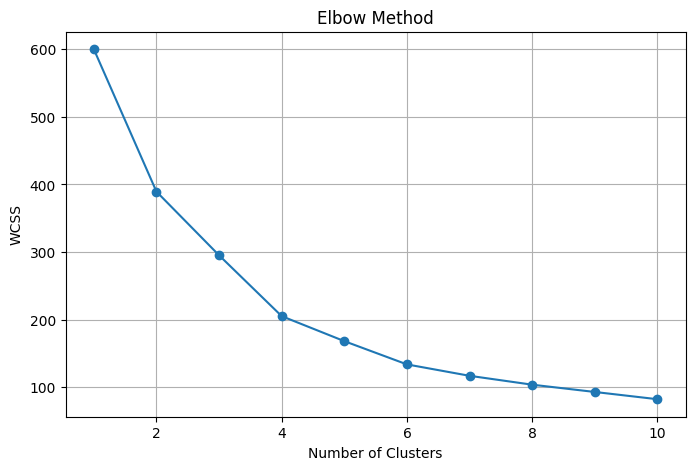

In [60]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.plot(

    range(1,11),

    wcss,

    marker="o"

)

plt.title(

    "Elbow Method"

)

plt.xlabel(

    "Number of Clusters"

)

plt.ylabel(

    "WCSS"

)

plt.grid(True)

plt.show()

In [61]:
kmeans=KMeans(n_clusters=5, random_state=42,n_init=10)
clusters=kmeans.fit_predict(X_scaled)
df['clusters']=clusters
print(df['clusters'].value_counts())

clusters
1    54
4    47
2    40
3    39
0    20
Name: count, dtype: int64


In [62]:
joblib.dump(kmeans, "kmeans_customer_model.pkl"
)
print("\nK-Means Model Saved Successfully")


K-Means Model Saved Successfully


In [63]:
print(kmeans.cluster_centers_)
silhouette=silhouette_score(X_scaled,clusters)
davies_bouldin=davies_bouldin_score(X_scaled,clusters)
calinski_harabasz=calinski_harabasz_score(X_scaled,clusters)
print(silhouette,davies_bouldin,calinski_harabasz)

[[ 0.5310735  -1.2905084  -1.23646671]
 [-0.98067852 -0.74305983  0.46744035]
 [-0.42880597  0.97484722  1.21608539]
 [ 0.07333084  0.97494509 -1.19729675]
 [ 1.20484056 -0.23577338 -0.05236781]]
0.41664341513732767 0.874551051002418 125.10094020060954


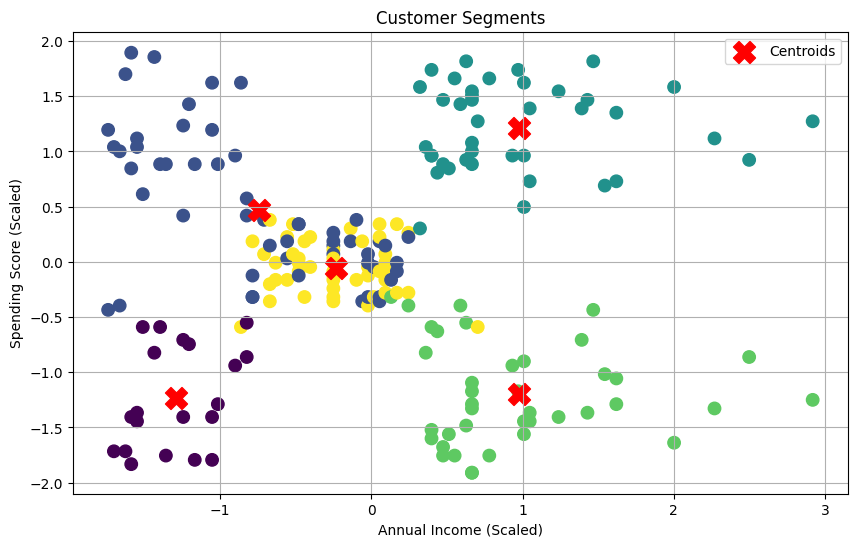

In [64]:

plt.figure(figsize=(10,6))

plt.scatter(

    X_scaled[:,1],

    X_scaled[:,2],

    c=clusters,

    cmap="viridis",

    s=80

)

plt.scatter(

    kmeans.cluster_centers_[:,1],

    kmeans.cluster_centers_[:,2],

    color="red",

    marker="X",

    s=250,

    label="Centroids"

)

plt.title(

    "Customer Segments"

)

plt.xlabel(

    "Annual Income (Scaled)"

)

plt.ylabel(

    "Spending Score (Scaled)"

)

plt.legend()

plt.grid(True)

plt.show()


In [65]:
print("\nCustomers in Each Cluster")

print(

    df["clusters"].value_counts()

)


cluster_summary = df.groupby(

    "clusters"

)[

    [

        "Age",

        "Annual Income (k$)",

        "Spending Score (1-100)"

    ]

].mean()

print("\nclusters Summary")

print(cluster_summary)



Customers in Each Cluster
clusters
1    54
4    47
2    40
3    39
0    20
Name: count, dtype: int64

clusters Summary
                Age  Annual Income (k$)  Spending Score (1-100)
clusters                                                       
0         46.250000           26.750000               18.350000
1         25.185185           41.092593               62.240741
2         32.875000           86.100000               81.525000
3         39.871795           86.102564               19.358974
4         55.638298           54.382979               48.851064


In [66]:
Customer=[[30,60,75]]
loaded_scaler=joblib.load('kmeans_scaler.pkl')
customer_scaler=loaded_scaler.transform(Customer)


loaded_model = joblib.load(

    "kmeans_customer_model.pkl"

)


cluster = loaded_model.predict(

    customer_scaler

)

print("\nPredicted Cluster")

print(cluster[0])


Predicted Cluster
1


c:\Users\Shah\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
